<a href="https://colab.research.google.com/github/saadi223/AI-based-blood_damage_model/blob/main/blood_damage_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Damage Prediction Model: A Machine Learning Approach

## 1. Data Loading and Initial Inspection

This section loads the dataset into a Pandas DataFrame and performs an initial inspection to understand its structure, size, and the first few entries. This is a crucial first step in any data science project to familiarize ourselves with the data we'll be working with.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('FYP_Physics_Informed_Dataset.csv')

print("Data shape (Rows, Columns):", df.shape)
display(df.head()) # Display the first 5 rows

Data shape (Rows, Columns): (427, 15)


,device_type,flow_rate_ml_min,inlet_diameter_mm,vol_avg_shear_rate,max_wall_shear_rate,p95_wall_shear_rate,throat_avg_shear_rate,vol_avg_exposure_time,max_exposure_time,throat_exposure_time,hydraulic_diameter_mm,target_log10_hi,vol_physics_index,throat_physics_index,max_physics_index
0,baseline,10,1.6,31.976647,3829.154433,3570.107782,154.259711,9.590000e-11,1.610000e-07,5.010000e-16,2.08,-10.364940,9.810000e-08,1.190000e-11,2.360650
1,baseline,11,1.6,35.177363,4212.620047,3927.118185,169.648624,8.760000e-11,1.470000e-07,5.010000e-16,2.08,-10.325546,1.080000e-07,1.440000e-11,2.608687
2,baseline,12,1.6,38.378858,4596.085662,4284.128589,185.037537,8.060000e-11,1.340000e-07,6.300000e-11,2.08,-10.264360,1.190000e-07,2.160000e-06,2.830616
3,baseline,13,1.6,41.580130,4979.550027,4641.140242,200.447830,7.470000e-11,1.430000e-07,5.830000e-11,2.08,-10.216936,1.290000e-07,2.340000e-06,3.545816
4,baseline,14,1.6,44.782628,5363.051879,4998.150645,215.845651,6.950000e-11,1.590000e-07,5.420000e-11,2.08,-10.164675,1.390000e-07,2.530000e-06,4.573210


### 1.1 Initial Data Overview

After loading the dataset, it's essential to get a quick overview. This typically involves checking the dimensions of the dataset (number of rows and columns) and displaying the first few rows to understand the features (columns) and the type of data they contain. This helps in identifying potential issues like missing values, incorrect data types, or outliers early on.

## 2. Data Preprocessing and Feature Engineering

Data preprocessing is a critical step to prepare the raw data for machine learning models. This often involves handling skewed distributions, transforming categorical variables into numerical representations, and removing redundant features. In this section, we will apply log transformation to highly skewed numerical features and one-hot encode the `device_type` categorical column.

In [13]:
# Add a small number to handle zeros during log transformation
epsilon = 1e-20

# List of columns to transform
skewed_cols = ['vol_avg_exposure_time', 'max_exposure_time', 'throat_exposure_time',
               'vol_physics_index', 'throat_physics_index', 'max_physics_index',
               'vol_avg_shear_rate', 'max_wall_shear_rate', 'p95_wall_shear_rate', 'throat_avg_shear_rate']

# Apply log transformation
for col in skewed_cols:
    df[f'log10_{col}'] = np.log10(df[col] + epsilon)

# Drop the original skewed columns
df = df.drop(columns=skewed_cols)

# Convert 'device_type' (text column) into numerical (0, 1) using one-hot encoding for Machine Learning
df = pd.get_dummies(df, columns=['device_type'], drop_first=True)

print("Features after cleaning:")
display(df.head())

Features after cleaning:


,flow_rate_ml_min,inlet_diameter_mm,hydraulic_diameter_mm,target_log10_hi,log10_vol_avg_exposure_time,log10_max_exposure_time,log10_throat_exposure_time,log10_vol_physics_index,log10_throat_physics_index,log10_max_physics_index,log10_vol_avg_shear_rate,log10_max_wall_shear_rate,log10_p95_wall_shear_rate,log10_throat_avg_shear_rate,device_type_herringbone,device_type_reduced_gap,device_type_reducedport
0,10,1.6,2.08,-10.364940,-10.018181,-6.793174,-15.300154,-7.008331,-10.924453,0.373032,1.504833,3.583103,3.552681,2.188253,False,False,False
1,11,1.6,2.08,-10.325546,-10.057496,-6.832683,-15.300154,-6.966576,-10.841638,0.416422,1.546263,3.624552,3.594074,2.229550,False,False,False
2,12,1.6,2.08,-10.264360,-10.093665,-6.872895,-10.200659,-6.924453,-5.665546,0.451881,1.584092,3.662388,3.631862,2.267260,False,False,False
3,13,1.6,2.08,-10.216936,-10.126679,-6.844664,-10.234331,-6.889410,-5.630784,0.549716,1.618886,3.697190,3.666625,2.302001,False,False,False
4,14,1.6,2.08,-10.164675,-10.158015,-6.798603,-10.266001,-6.856985,-5.596879,0.660221,1.651110,3.729412,3.698809,2.334143,False,False,False


### 2.1 Handling Skewed Distributions and Categorical Features

Many machine learning models assume that numerical features are normally distributed. Highly skewed distributions can negatively impact model performance. Log transformation is a common technique used to reduce skewness and stabilize variance. Additionally, machine learning models typically require numerical input, so categorical features like `device_type` must be converted. One-hot encoding is a popular method that transforms categorical variables into a binary (0 or 1) numerical format, creating new columns for each category. We are dropping the `epsilon` to handle potential zero values in log transformation and avoiding errors.

### 2.2 Restructuring Data Preprocessing into a Module

To adhere to best practices for a machine learning project, we will encapsulate the data preprocessing logic into a dedicated Python module: `src/data_preprocessing.py`. This promotes modularity, reusability, and maintainability of the code. The main notebook will then simply import and call the `preprocess_data` function from this module.

In [14]:
from sklearn.model_selection import train_test_split

# Separate the target column
y = df['target_log10_hi']
X = df.drop(columns=['target_log10_hi'])

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (341, 16)
Testing data size: (86, 16)


## 3. Data Splitting: Training and Testing Sets

To build a robust machine learning model, it's crucial to evaluate its performance on unseen data. This is achieved by splitting the dataset into two parts: a training set and a testing set. The model learns from the training data, and its performance is then assessed on the testing data. A common split ratio is 80% for training and 20% for testing. The `random_state` parameter ensures reproducibility of the split.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model RMSE (Error): {rmse:.4f}")
print(f"Model Accuracy (R2 Score): {r2:.4f} (1.0 is the best possible score)")

Model RMSE (Error): 0.2792
Model Accuracy (R2 Score): 0.9846 (1.0 is the best possible score)


## 4. Model Training and Evaluation

For this project, we will employ a RandomForestRegressor. Random Forests are powerful ensemble learning methods that work by constructing a multitude of decision trees during training and outputting the mean prediction (regression) of the individual trees. They are known for their high accuracy and ability to handle complex datasets.

After training, the model's performance is evaluated using key metrics:
- **Mean Squared Error (RMSE)**: Measures the average magnitude of the errors. It's the square root of the average squared differences between predicted and actual values. Lower RMSE indicates better fit.
- **R-squared (R2 Score)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of 1.0 indicates that the model perfectly predicts the target variable.

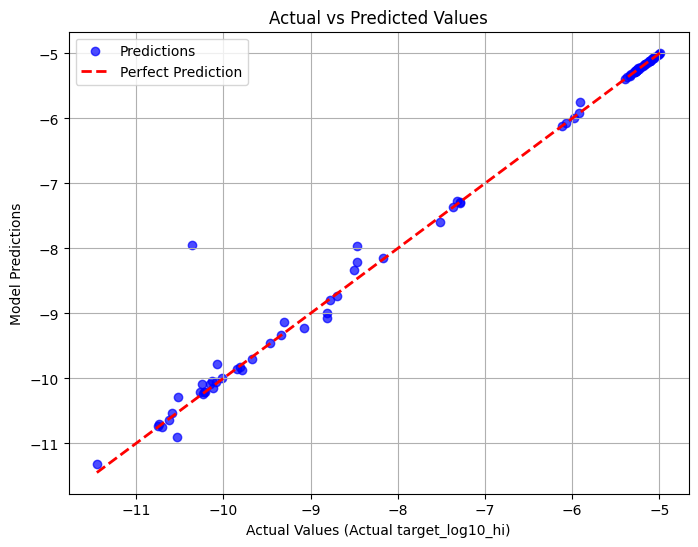

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')

# A straight line representing Perfect Prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values (Actual target_log10_hi)')
plt.ylabel('Model Predictions')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

### 4.1 Visualizing Model Performance: Actual vs. Predicted Values

A scatter plot of actual versus predicted values is an effective way to visually assess a regression model's performance. Ideally, the predicted values should align closely with the actual values, forming a straight line. A perfect model would show all points lying exactly on the `y = x` line (the red dashed line in the plot), indicating perfect predictions. Deviations from this line highlight areas where the model's predictions differ from the true values.

/tmp/ipykernel_1548/3471117526.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


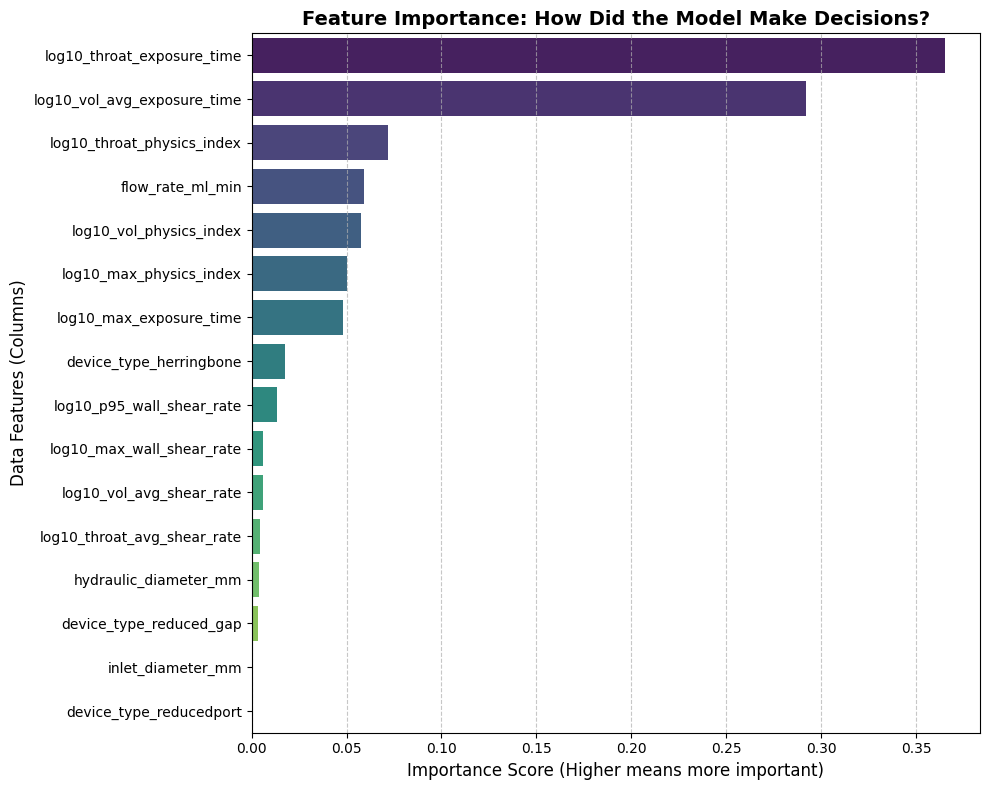

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame to organize the data
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance to place the most important features at the top
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a Horizontal Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Make the graph beautiful and easy to understand
plt.title('Feature Importance: How Did the Model Make Decisions?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Higher means more important)', fontsize=12)
plt.ylabel('Data Features (Columns)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

Understanding which features contribute most to the model's predictions is crucial for interpretability and potential feature selection. Random Forest models provide a `feature_importances_` attribute, which quantifies the contribution of each feature to the model's decision-making process. Features with higher importance scores have a greater impact on the predicted outcome. This analysis helps in identifying key drivers and can guide further optimization by focusing on the most influential variables.

In [18]:
# 1. Select only the most important (top) features identified in the graph
top_features = [
    'log10_throat_exposure_time',
    'log10_vol_avg_exposure_time',
    'log10_throat_physics_index',
    'flow_rate_ml_min',
    'log10_vol_physics_index',
    'log10_max_physics_index'
]

### 5.1 Selecting Top Features for Model Optimization

Based on the feature importance analysis, we can identify and select the most influential features. By using only these top features, we aim to simplify the model, reduce noise, potentially improve generalization, and decrease computational costs without significantly sacrificing predictive performance. This step is a form of dimensionality reduction, focusing the model on the most relevant information.

In [19]:
# X will now only contain these selected top features (redundant columns dropped)
X_optimized = X[top_features]

# 2. Split the data again into Training and Testing sets
X_train_opt, X_test_opt, y_train, y_test = train_test_split(
    X_optimized, y, test_size=0.2, random_state=42
)

print(f"The old model had {X.shape[1]} columns.")
print(f"The new Optimized model has only {X_optimized.shape[1]} columns!\n")

The old model had 16 columns.
The new Optimized model has only 6 columns!



## 6. Training an Optimized Model with Selected Features

With the top features identified, we now retrain our RandomForestRegressor using only this reduced set of features. This process not only confirms the effectiveness of feature selection but also creates a more parsimonious model. A model with fewer features is often easier to interpret and less prone to overfitting, especially when dealing with high-dimensional data.

The data is re-split to ensure that the training and testing sets are consistent with the new feature subset.

In [20]:
# 3. Train the new Optimized Model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train_opt, y_train)

RandomForestRegressor(random_state=42)

### 6.1 Evaluating the Optimized Model

After training the model with the optimized feature set, we re-evaluate its performance using the same metrics: RMSE and R2 score. Comparing these metrics to the initial model's performance helps determine if feature selection led to an improvement (e.g., lower RMSE, higher R2) or maintained similar performance with a simpler model. This step is critical for validating the benefits of feature engineering.

In [21]:
# 4. Check the results to see the difference in performance
y_pred_opt = final_model.predict(X_test_opt)
r2_opt = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"Optimized Model Accuracy (R2): {r2_opt:.4f}")
print(f"Optimized Model RMSE (Error): {rmse_opt:.4f}\n")

Optimized Model Accuracy (R2): 0.9894
Optimized Model RMSE (Error): 0.2314



## 7. Model Deployment: Saving the Optimized Model

Once the optimized model has been trained and validated, it's ready for deployment. The final step in a machine learning project is often to save the trained model so it can be loaded and used later for making predictions on new, unseen data without needing to retrain it. The `joblib` library is a popular choice for this, as it's efficient for large NumPy arrays and objects with Python references, making it suitable for scikit-learn models. The model is saved as a `.pkl` (pickle) file.

In [22]:
import joblib

# 5. Save the model for Production (.pkl file)
joblib.dump(final_model, 'blood_damage_model_optimized.pkl')
print("Congratulations! The model has been successfully saved as 'blood_damage_model_optimized.pkl'.")

Congratulations! The model has been successfully saved as 'blood_damage_model_optimized.pkl'.


## 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a crucial step to understand the dataset's characteristics, identify patterns, detect outliers, and uncover relationships between variables. This section will delve deeper into the data to gain insights that can further inform model improvements or interpretations.

### 8.1 Distribution of Numerical Features

Visualizing the distribution of numerical features helps us understand their spread, central tendency, and identify any skewness or unusual patterns. Histograms are an excellent tool for this purpose, providing a visual representation of the frequency of values within different ranges.

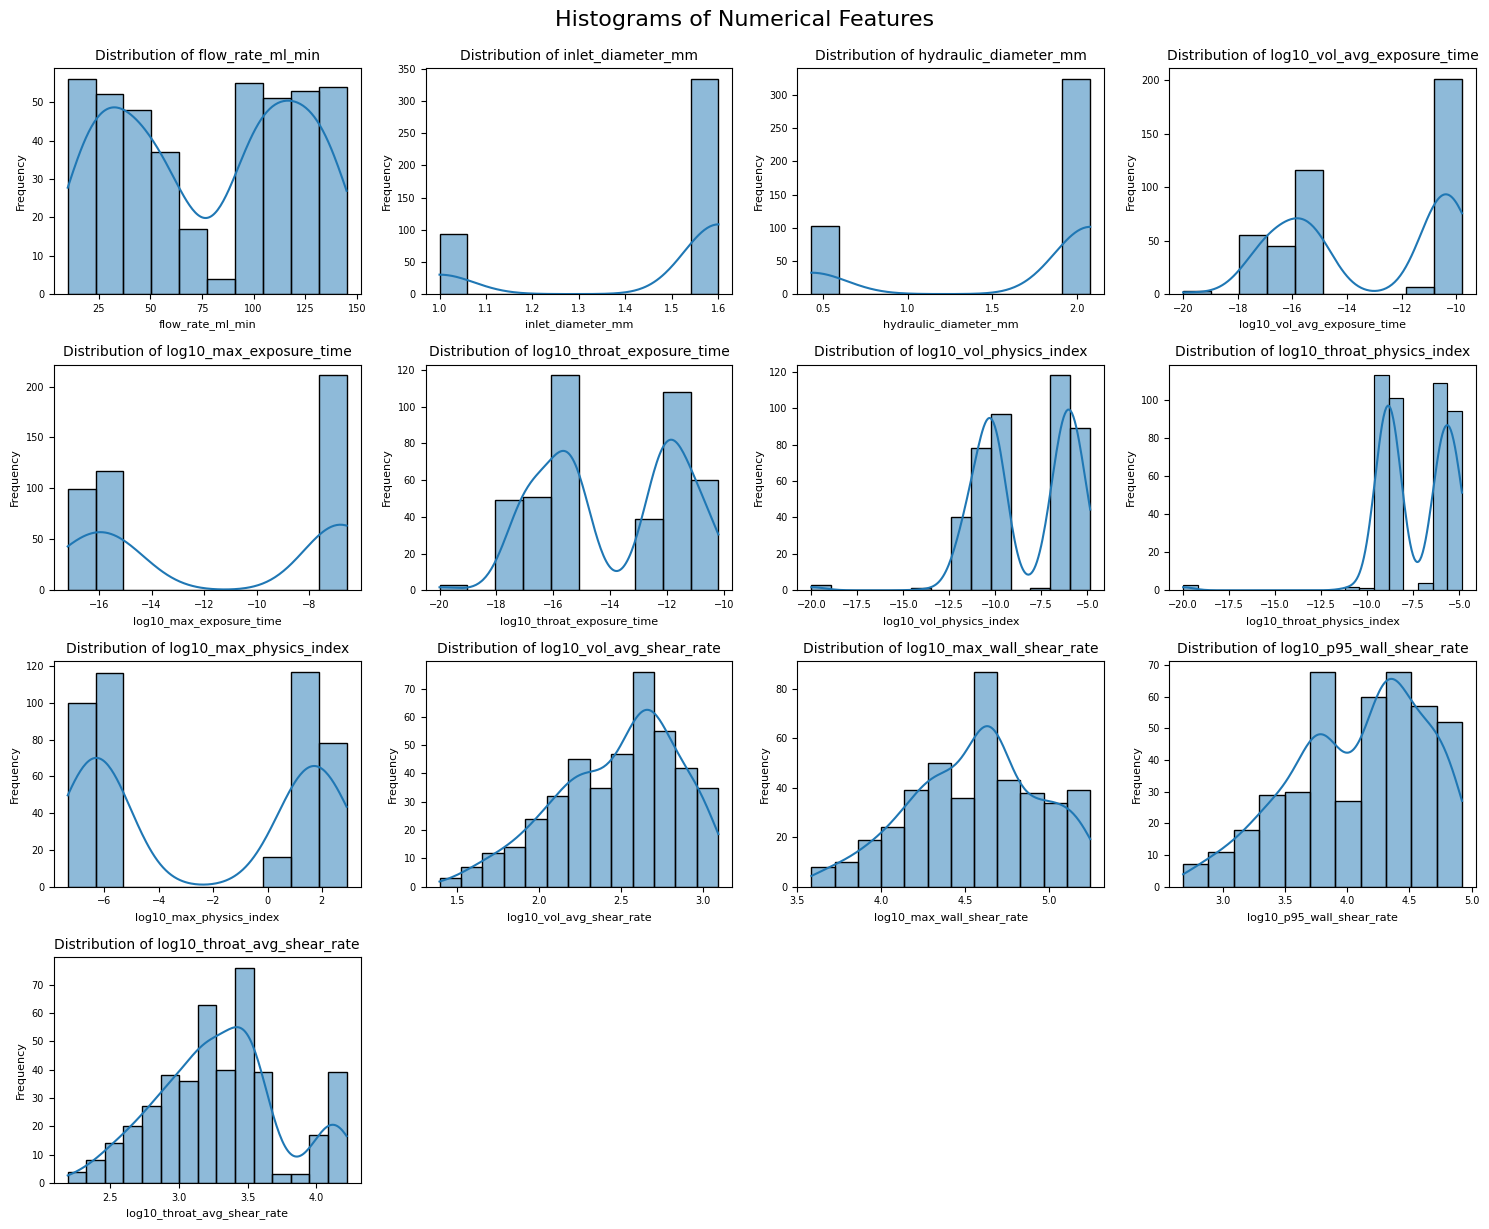

In [23]:
# Get all numerical columns (excluding the target and one-hot encoded device types if they are still present as separate columns after the previous steps)
numerical_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust subplot grid based on number of numerical features
    sns.histplot(X[col], kde=True) # Use X dataframe for features
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel(col, fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.show()

### 8.2 Correlation Matrix and Heatmap

Correlation analysis helps us understand the linear relationships between numerical variables. A correlation matrix displays the correlation coefficients between all pairs of variables, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation). A heatmap provides a visual representation of this matrix, making it easy to spot strong correlations. This is particularly useful for identifying multicollinearity among features, which can sometimes negatively impact model performance, or for finding features highly correlated with the target variable.

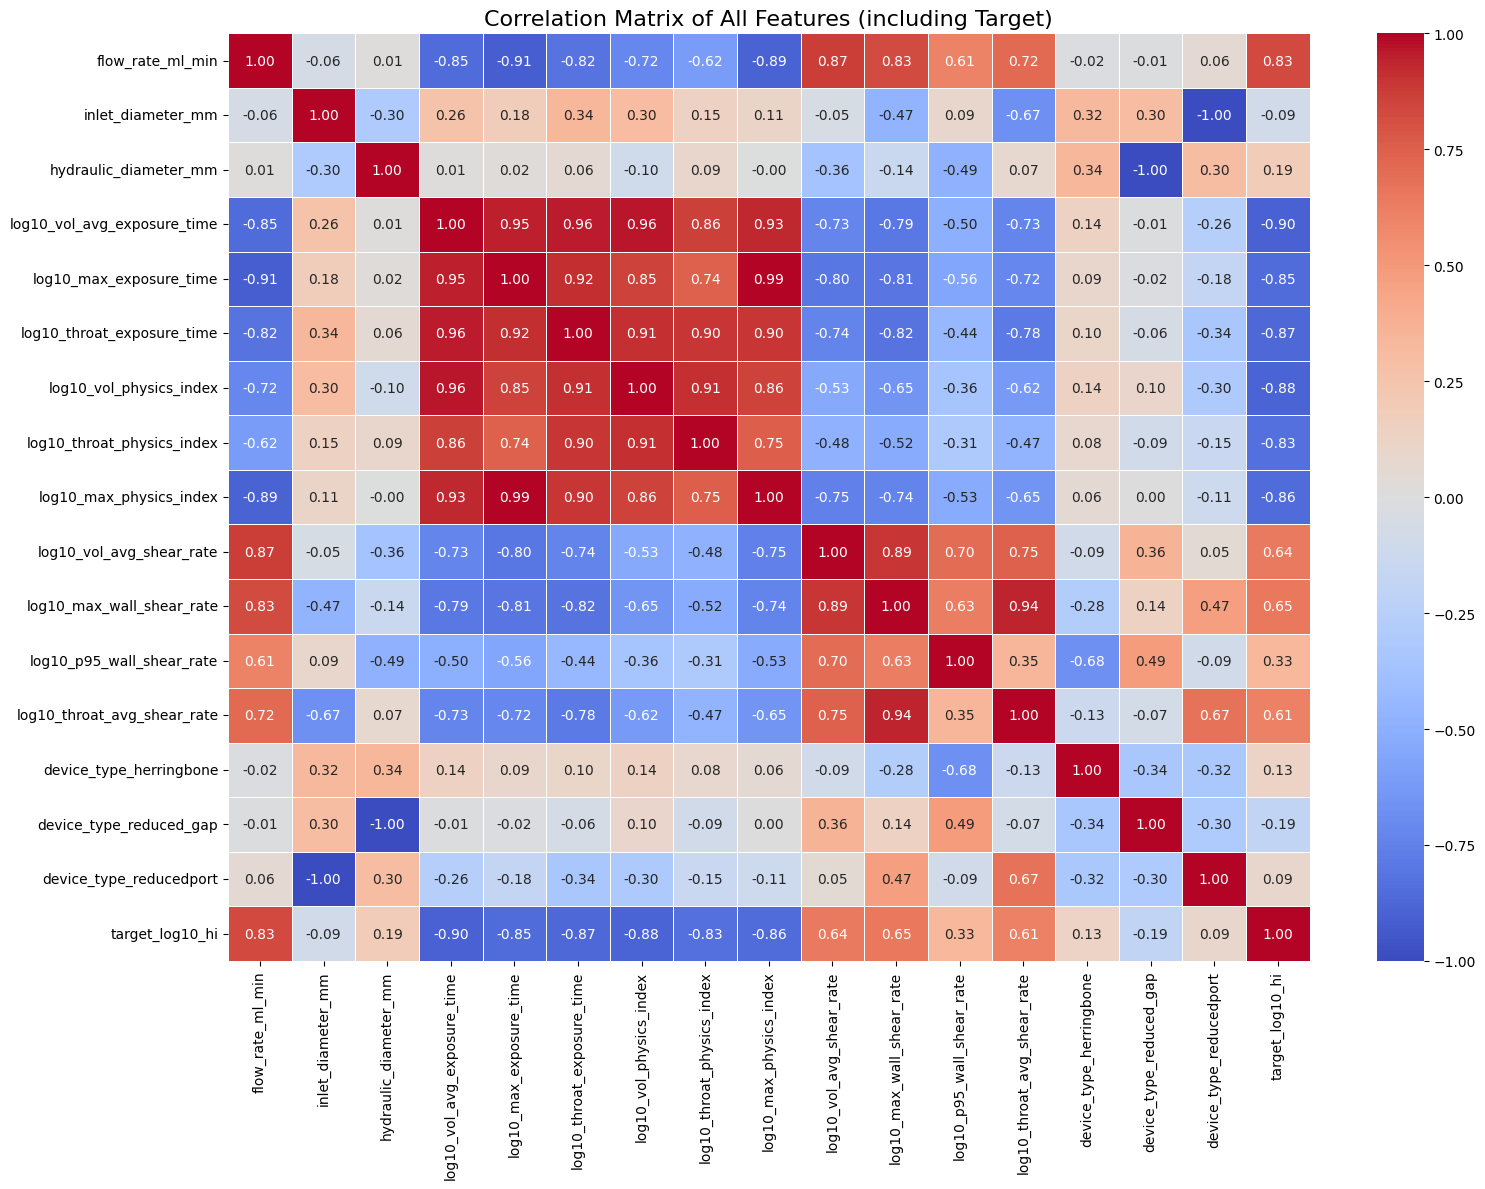

In [24]:
# Combine X (features) and y (target) back for correlation analysis
df_eda = pd.concat([X, y], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_eda.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (including Target)', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 8.3 Feature vs. Target Relationship Plots

To further understand the individual impact of the most important features on our target variable (`target_log10_hi`), we will visualize their relationships using scatter plots. These plots can reveal linear or non-linear trends, clusters, or outliers that might not be immediately apparent from correlation matrices. This granular view helps confirm the rationale behind feature selection and can inspire further feature engineering.

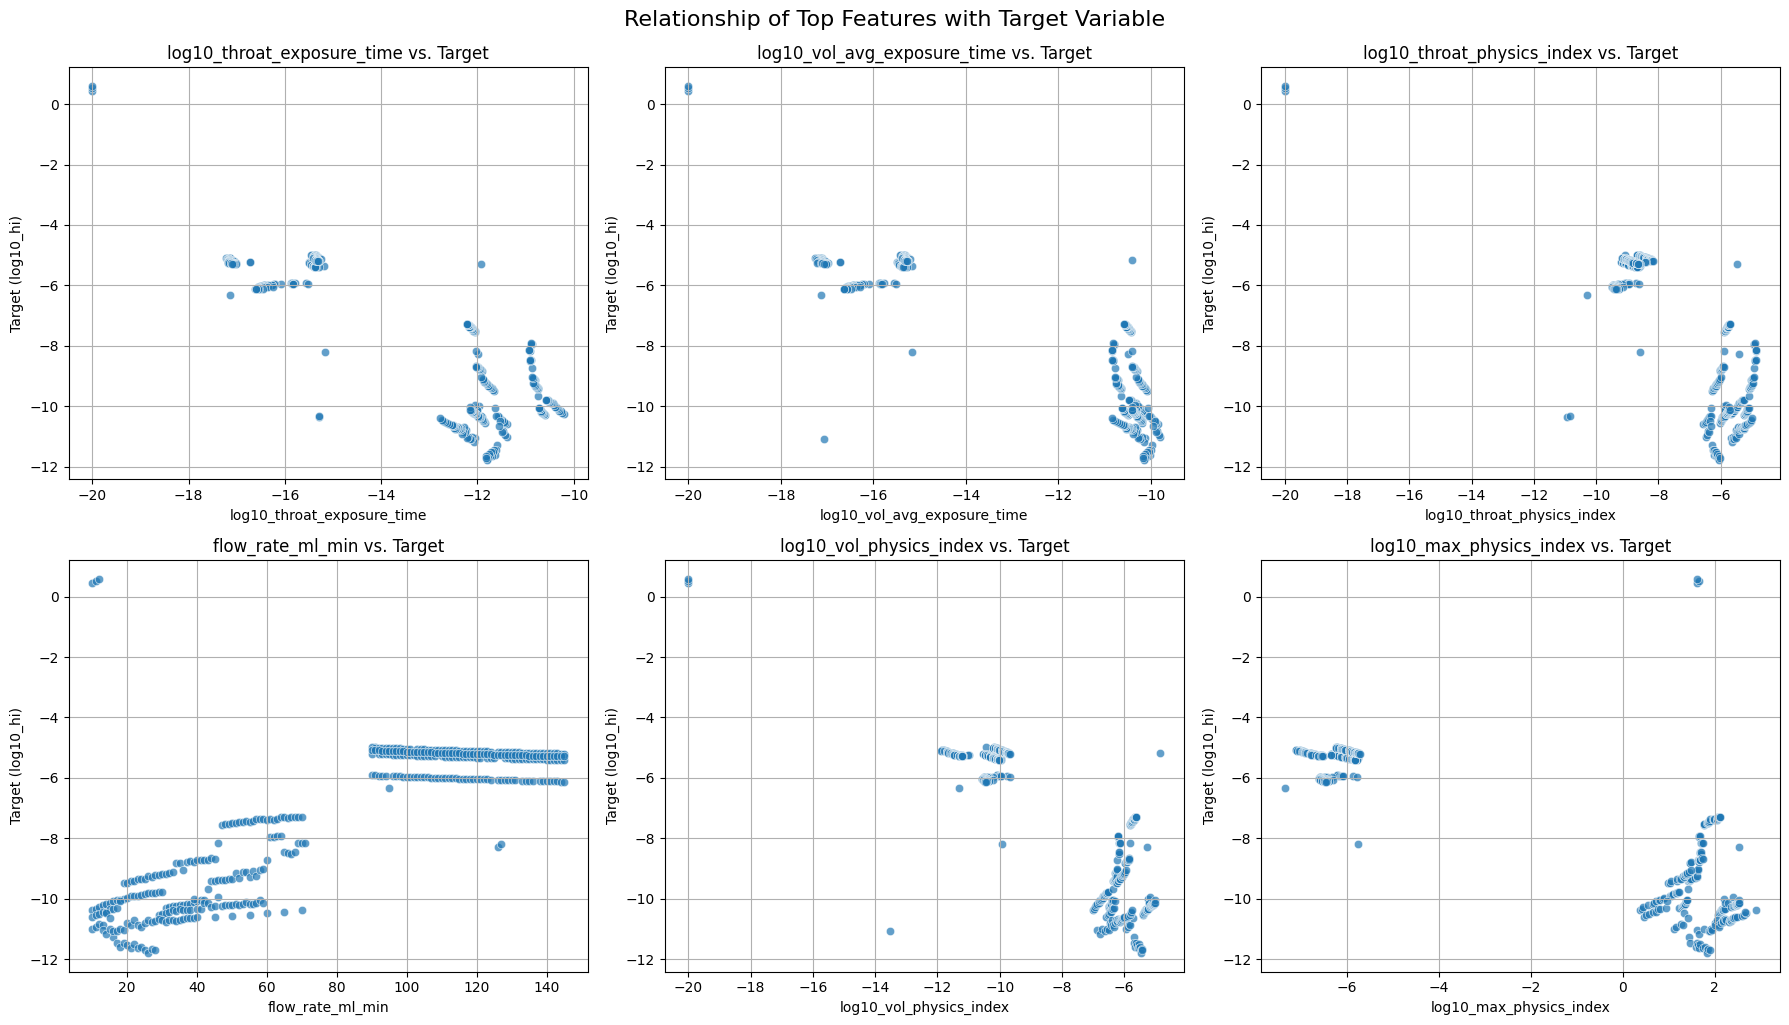

In [25]:
# Using the top features identified earlier

plt.figure(figsize=(18, 10))
for i, col in enumerate(top_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of top features
    sns.scatterplot(x=df_eda[col], y=df_eda['target_log10_hi'], alpha=0.7)
    plt.title(f'{col} vs. Target', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Target (log10_hi)', fontsize=10)
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Relationship of Top Features with Target Variable', y=1.02, fontsize=16)
plt.show()

### 8.4 Descriptive Statistics of Numerical Features

Descriptive statistics provide a quantitative summary of the main characteristics of our numerical features. This includes measures of central tendency (mean, median), dispersion (standard deviation, variance, interquartile range), and shape of the distribution (skewness, kurtosis). This overview helps in identifying potential issues like extreme values, data entry errors, or features with very little variance, which might not be useful for modeling.

In [26]:
# Display descriptive statistics for numerical columns in the features DataFrame (X)
display(X.describe().T)

# Also, show descriptive statistics for the target variable (y)
print("\nDescriptive Statistics for Target Variable (target_log10_hi):")
display(y.describe())

,count,mean,std,min,25%,50%,75%,max
flow_rate_ml_min,427.0,77.901639,43.478554,10.000000,36.000000,90.000000,117.500000,145.000000
inlet_diameter_mm,427.0,1.469321,0.247940,1.000000,1.600000,1.600000,1.600000,1.600000
hydraulic_diameter_mm,427.0,1.681991,0.706735,0.430000,2.080000,2.080000,2.080000,2.080000
log10_vol_avg_exposure_time,427.0,-13.318355,2.936564,-20.000000,-15.838695,-15.267598,-10.397941,-9.795880
log10_max_exposure_time,427.0,-11.470913,4.630830,-17.190440,-15.653785,-15.182428,-6.786484,-6.590067
log10_throat_exposure_time,427.0,-13.936915,2.376877,-20.000000,-15.846286,-15.300154,-11.897940,-10.200659
log10_vol_physics_index,427.0,-8.380534,2.533049,-20.000000,-10.395786,-9.716699,-6.078602,-4.841638
log10_throat_physics_index,427.0,-7.388704,1.983149,-20.000000,-8.879476,-8.216811,-5.743538,-4.850781
log10_max_physics_index,427.0,-2.349424,4.037888,-7.353596,-6.274909,-5.744727,1.679261,2.911126
log10_vol_avg_shear_rate,427.0,2.479357,0.370533,1.391998,2.222192,2.553241,2.751747,3.091640



Descriptive Statistics for Target Variable (target_log10_hi):


,target_log10_hi
count,427.000000
mean,-7.464437
std,2.407213
min,-11.787369
25%,-10.059593
50%,-6.112362
75%,-5.241107
max,0.597266


### 8.5 Analysis of Categorical Features (One-Hot Encoded)

Although the `device_type` column was transformed using one-hot encoding into numerical binary columns, it's still valuable to understand the distribution of these categories. Visualizing the counts for each device type helps us see how balanced or imbalanced the dataset is across different device configurations. This can be important for understanding representation and potential biases in the data.

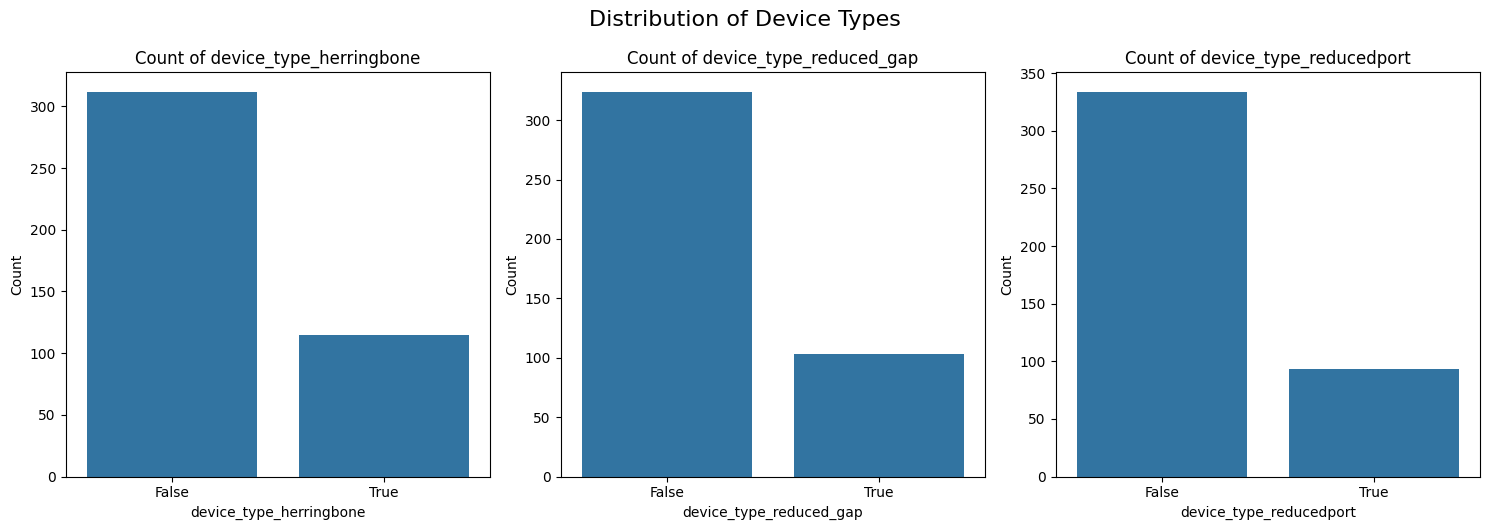

In [27]:
categorical_cols = ['device_type_herringbone', 'device_type_reduced_gap', 'device_type_reducedport']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1) # Adjust subplot grid
    sns.countplot(x=df_eda[col])
    plt.title(f'Count of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
plt.tight_layout()
plt.suptitle('Distribution of Device Types', y=1.05, fontsize=16)
plt.show()

### 8.6 Outlier Detection with Box Plots

Outliers are data points that significantly differ from other observations. They can skew statistical analyses and negatively impact machine learning model performance. Box plots are an effective way to visualize the distribution of numerical data and identify potential outliers, which are typically represented as points extending beyond the 'whiskers' of the box plot. This helps us understand the range and variability of each feature and pinpoint unusual data points.

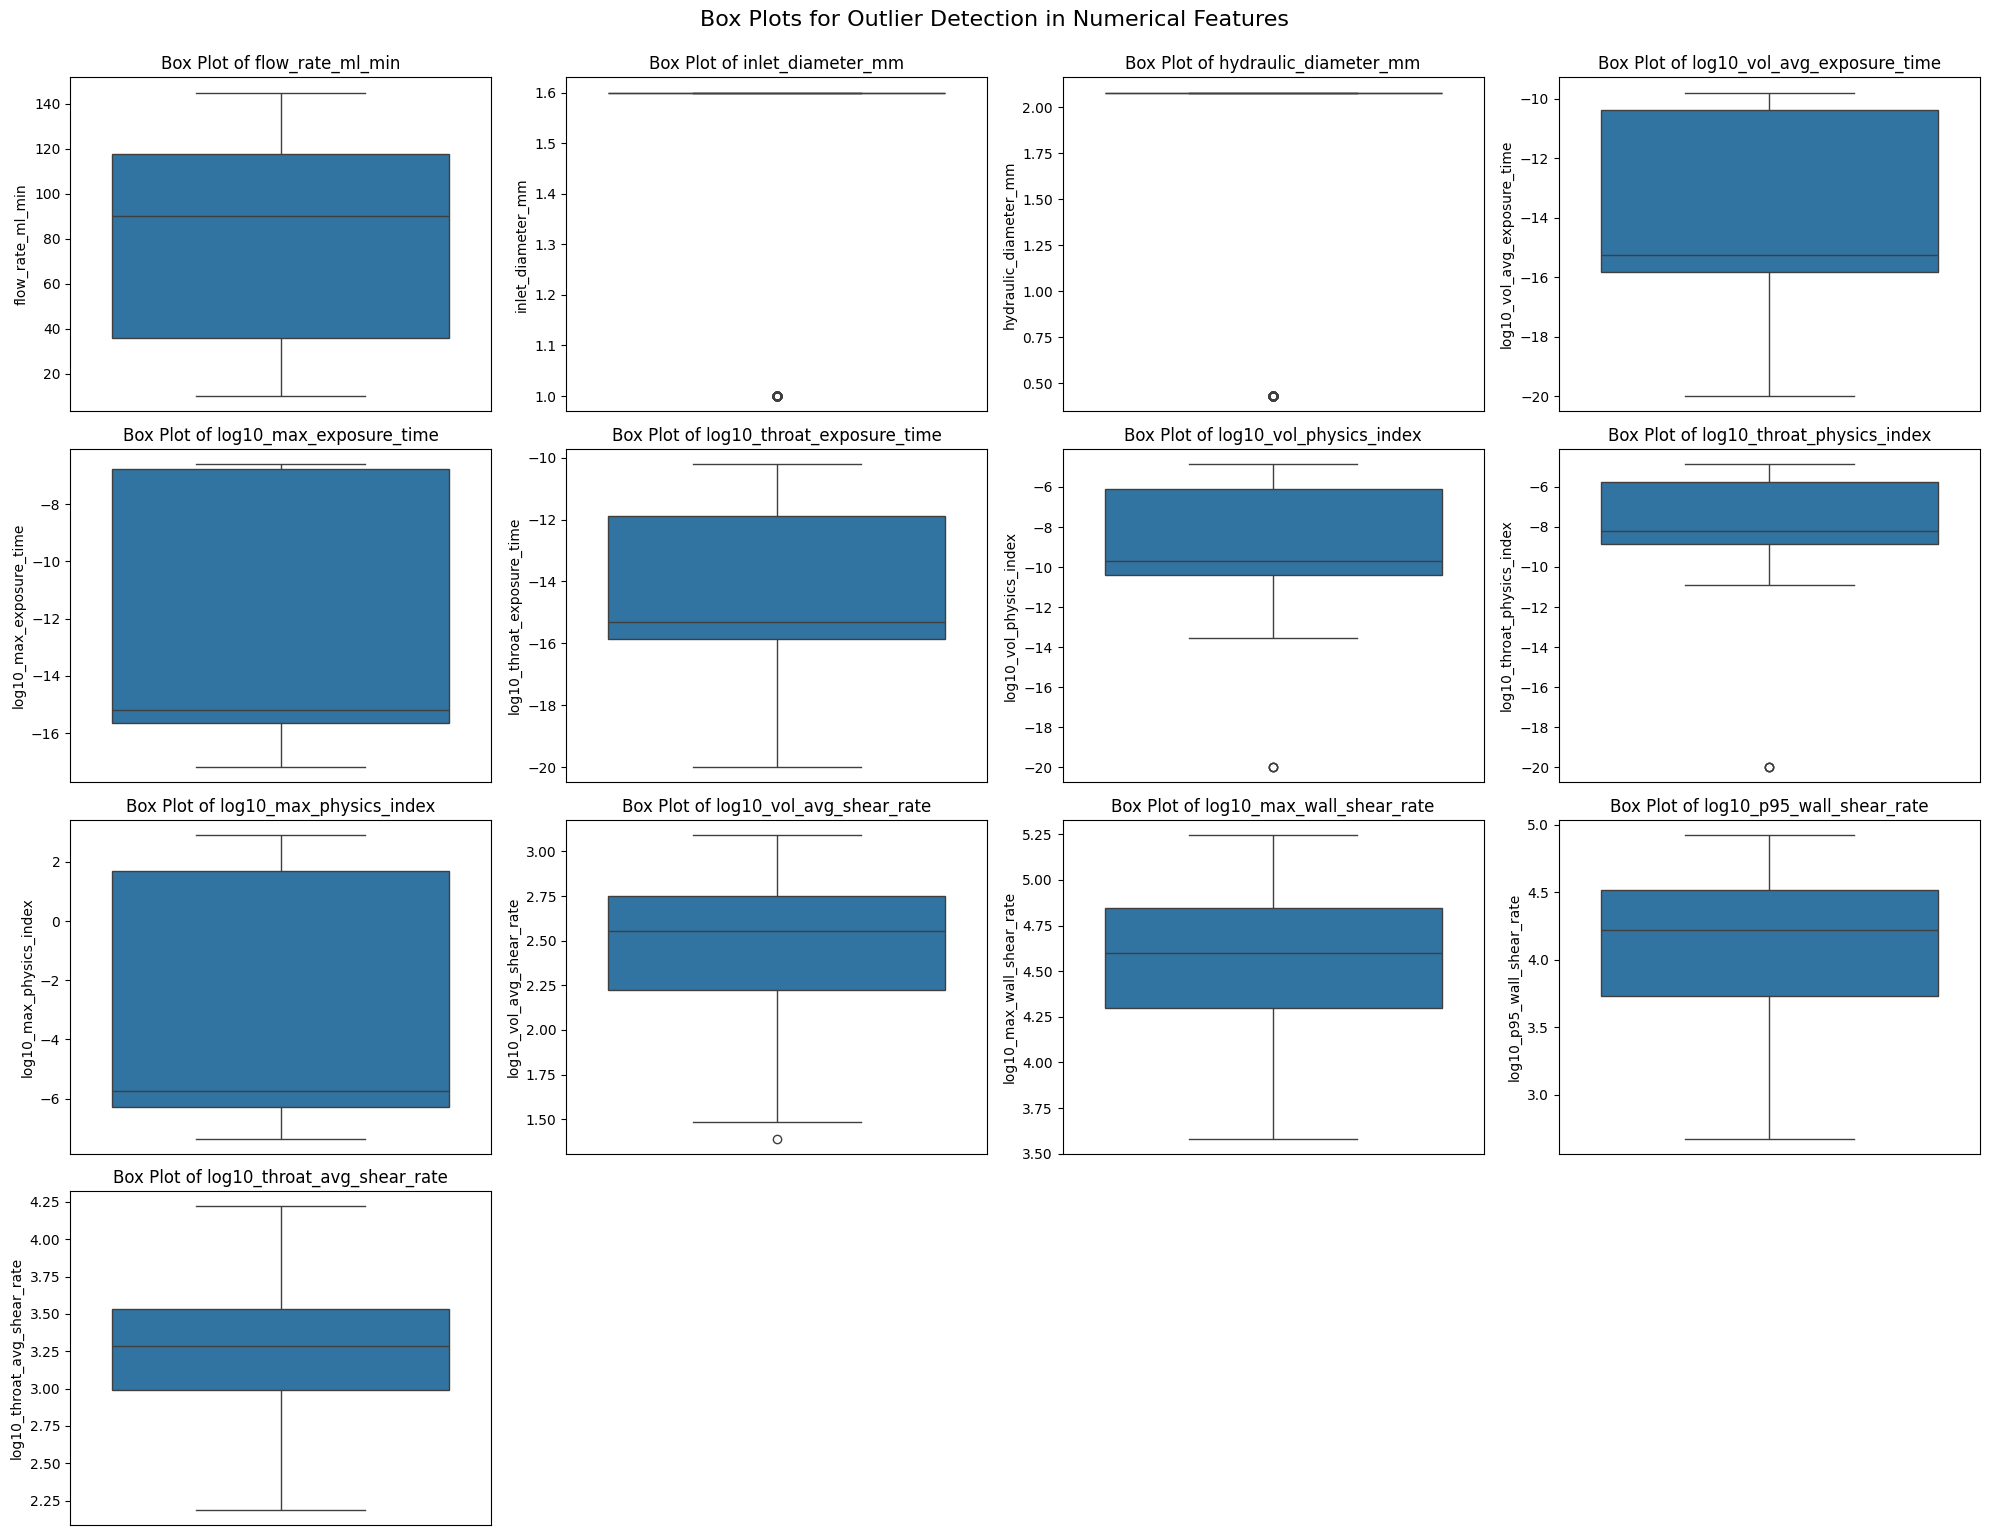

In [28]:
# Using the numerical features from X (excluding the one-hot encoded columns, as their distribution is already covered)
numerical_for_boxplot = X.select_dtypes(include=np.number).columns.tolist()
# Remove the one-hot encoded columns if they were included by select_dtypes
numerical_for_boxplot = [col for col in numerical_for_boxplot if col not in categorical_cols]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_for_boxplot):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid
    sns.boxplot(y=X[col])
    plt.title(f'Box Plot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.xticks([]) # Hide x-axis ticks for single box plots
plt.tight_layout()
plt.suptitle('Box Plots for Outlier Detection in Numerical Features', y=1.02, fontsize=16)
plt.show()

### 8.7 Comparing Numerical Feature Distributions Across Device Types

It's often insightful to see how the distributions of numerical features differ across various categories. In our case, comparing key numerical features across different `device_type` configurations can reveal how device design influences the physics-informed parameters. Violin plots are ideal for this, as they show both the distribution (density) and box plot elements (median, quartiles) for each group, providing a rich comparison.

/tmp/ipykernel_1548/855141679.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='device_type', y=feature, data=df_original, palette='viridis')
/tmp/ipykernel_1548/855141679.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='device_type', y=feature, data=df_original, palette='viridis')
/tmp/ipykernel_1548/855141679.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='device_type', y=feature, data=df_original, palette='viridis')
/tmp/ipykernel_1548/855141679.py:21: FutureWarning: 

Passing `palette` without assigning `hue

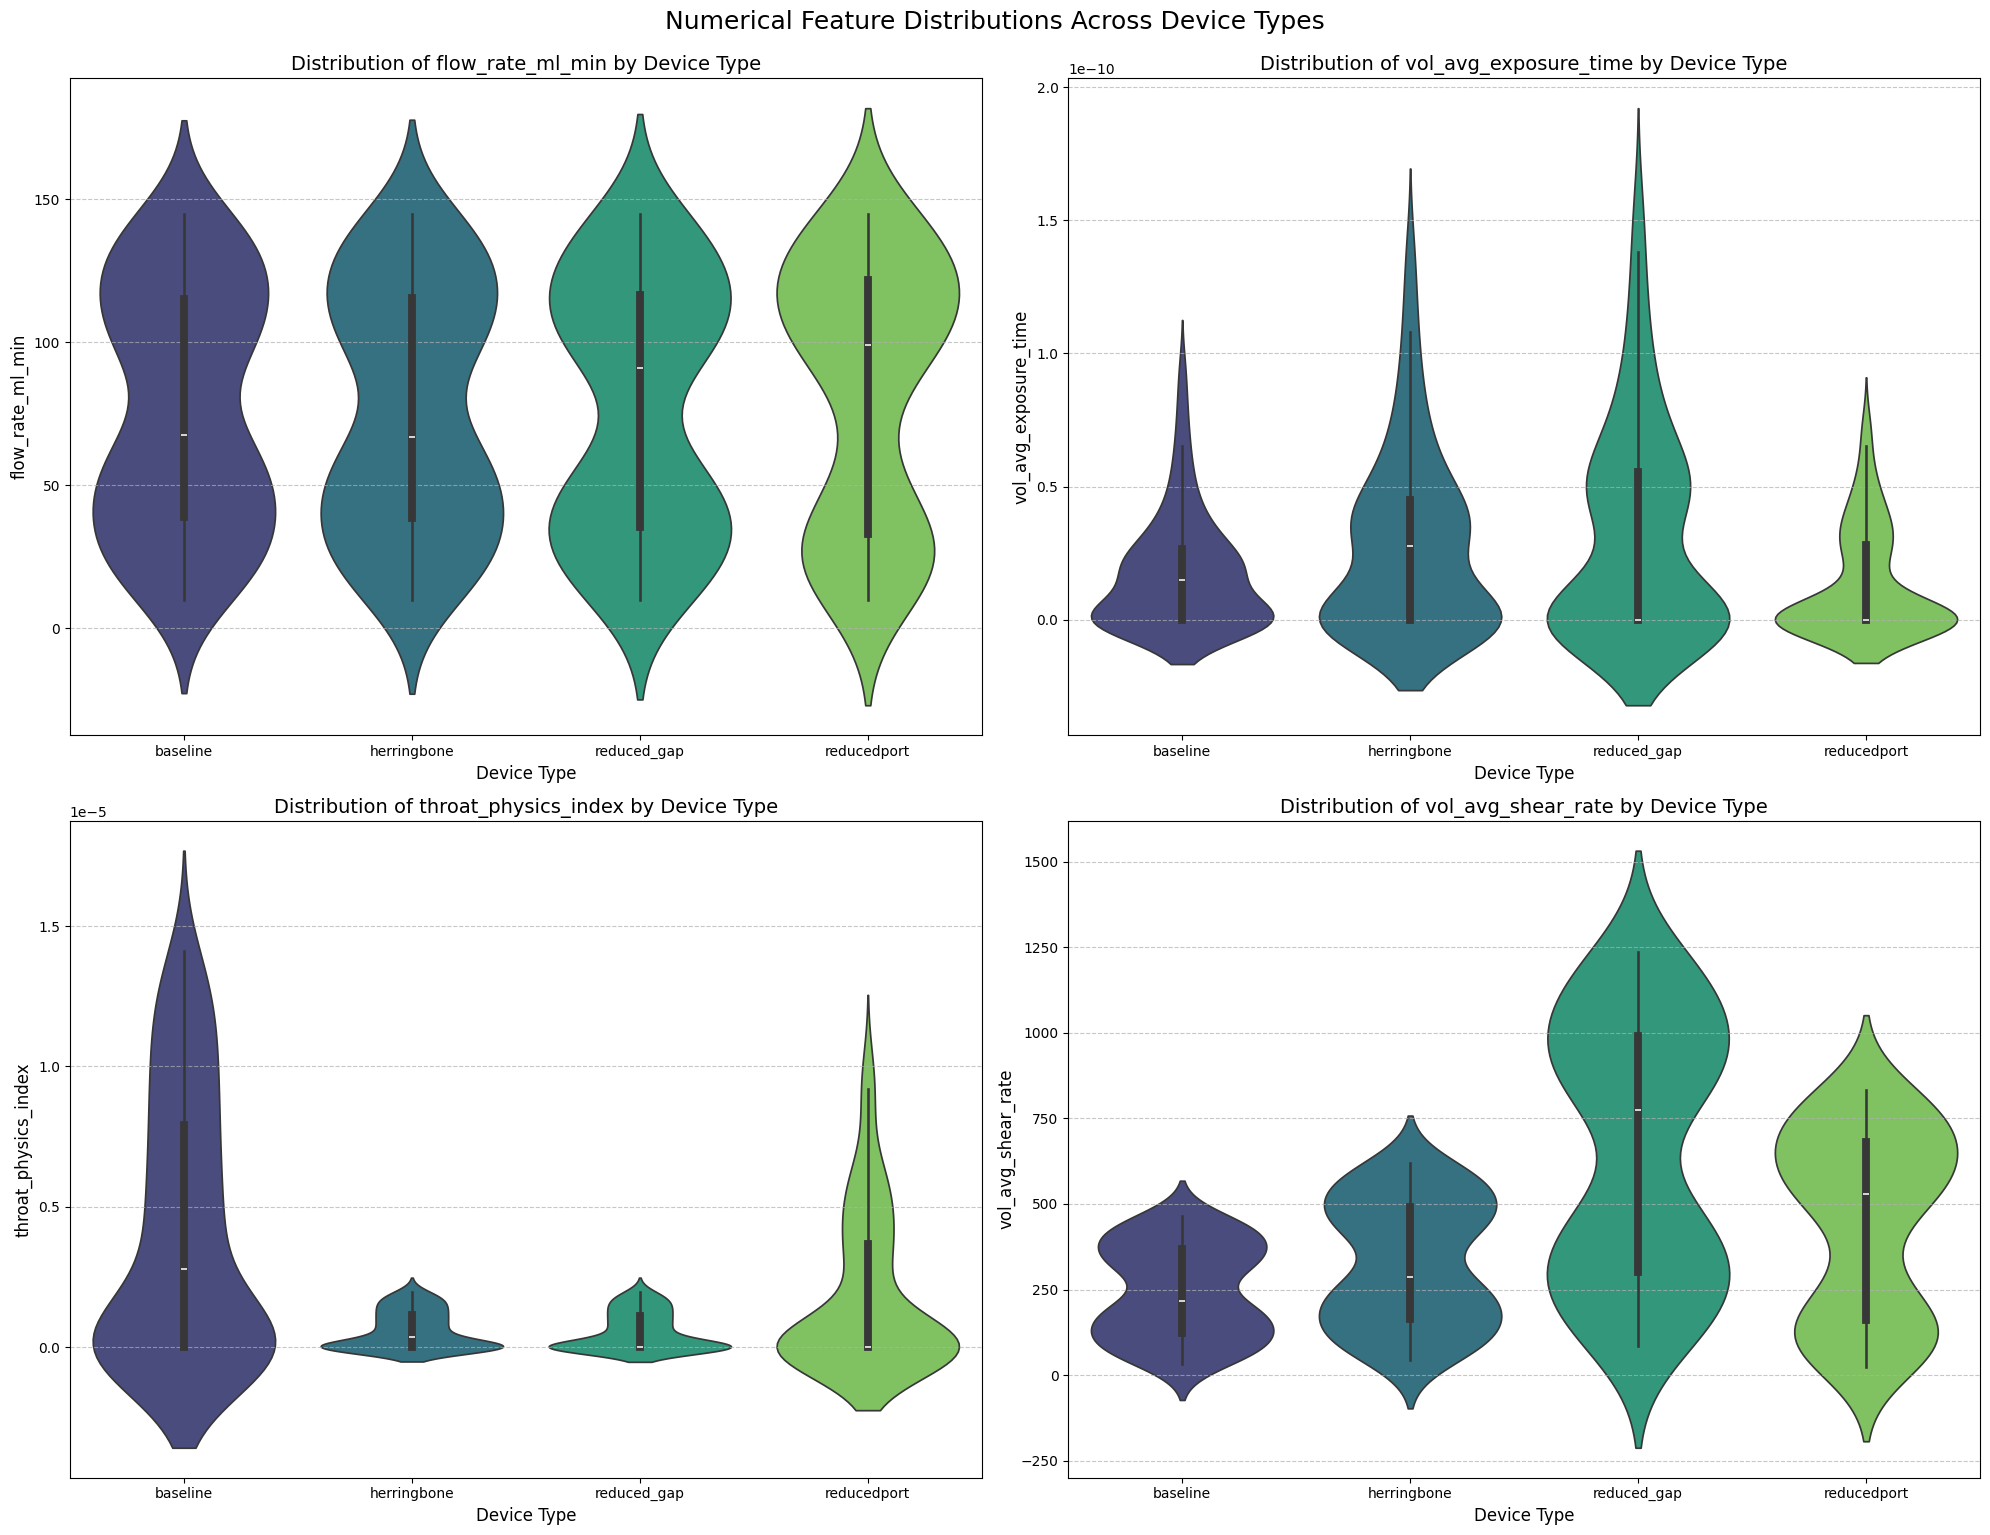

In [29]:
# To compare across device types, we need the original 'device_type' column.
# Let's re-load the original dataset or ensure 'device_type' is available in a temporary DataFrame for this EDA step.
# Assuming 'df' still contains the original 'device_type' or we create a new df_eda that includes it before one-hot encoding.

# For this visualization, we need the original 'device_type' column.
# Let's load the original dataset into a temporary DataFrame for this specific visualization.
df_original = pd.read_csv('FYP_Physics_Informed_Dataset.csv')

# Select a few key numerical features to compare across device types.
# We can use some of the 'top_features' or other interesting ones.
features_to_compare = [
    'flow_rate_ml_min',
    'vol_avg_exposure_time', # Original form, not log-transformed
    'throat_physics_index', # Original form
    'vol_avg_shear_rate' # Original form
]

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features_to_compare):
    plt.subplot(2, 2, i + 1)  # Adjust subplot grid
    sns.violinplot(x='device_type', y=feature, data=df_original, palette='viridis')
    plt.title(f'Distribution of {feature} by Device Type', fontsize=14)
    plt.xlabel('Device Type', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.suptitle('Numerical Feature Distributions Across Device Types', y=1.02, fontsize=18)
plt.show()

### 8.8 Checking for Missing Values

Missing data can introduce bias and reduce the accuracy of a model. It's important to identify the presence and extent of missing values in our dataset. This step involves counting the number of null values for each column and visualizing the results, which helps in deciding how to handle them (e.g., imputation, removal).

In [30]:
# Check for missing values in the combined DataFrame (df_eda which includes features and target)
missing_values = df_eda.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing Values by Column:")
    display(missing_values.sort_values(ascending=False))

    # Optionally, visualize missing values
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Missing Values Count by Feature', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

No missing values found in the dataset.
